In [ ]:
#importing necessary libraries
import numpy as np
import pandas as pd
import re
import tensorflow as tf
from tensorflow import keras
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.layers import Embedding
from transformers import RobertaTokenizer, TFRobertaForSequenceClassification
from tensorflow.keras.layers import Input, Dense, LSTM, SimpleRNN, Bidirectional
from tensorflow.keras.models import Model
from gensim.models import FastText
import torch
from transformers import DistilBertTokenizer, DistilBertModel
from top2vec import Top2Vec
from hdbscan import HDBSCAN
import umap
from transformers import pipeline
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix 

: 

In [ ]:
#loading dataset
data = pd.read_csv("C:/PYDATAFILES/SENTIMENT_ANALYSIS.csv",  encoding="latin1")
data.head()

,App_Name,Company_Name,Page_URL,Official_website,Email,Address,Privacy_policy,Name,Time,Year,Star_rating,Helpful,Comments,Developer_Reply
0,Equity Mobile,Equity Group,https://play.google.com/store/apps/details?id=...,https://equitygroupholdings.com/,info@equitybank.co.ke,NaN,https://equitygroupholdings.com/privacy-policy/,Edith Ngundi,"August 10, 2022",2022.0,1.0,117.0,Authentication process is hell. I've been tryi...,"Hello Edith, thank you for your interest in ou..."
1,Equity Mobile,Equity Group,https://play.google.com/store/apps/details?id=...,https://equitygroupholdings.com/,info@equitybank.co.ke,NaN,https://equitygroupholdings.com/privacy-policy/,Josephine Ouma,"July 18, 2024",2024.0,1.0,1.0,The current update is the Worst banking app ev...,"Hey Josephine, we are deeply sorry for the inc..."
2,Equity Mobile,Equity Group,https://play.google.com/store/apps/details?id=...,https://equitygroupholdings.com/,info@equitybank.co.ke,NaN,https://equitygroupholdings.com/privacy-policy/,Faisol Wesonga,"June 24, 2024",2024.0,2.0,13.0,An update should make an app better than befor...,"Hey Faisol, we are truly grateful for the feed..."
3,Equity Mobile,Equity Group,https://play.google.com/store/apps/details?id=...,https://equitygroupholdings.com/,info@equitybank.co.ke,NaN,https://equitygroupholdings.com/privacy-policy/,derick mwangi,"May 17, 2024",2024.0,3.0,52.0,"Overall, the app is very useful and has great ...","Hello Derick, thank you for sharing your exper..."
4,Equity Mobile,Equity Group,https://play.google.com/store/apps/details?id=...,https://equitygroupholdings.com/,info@equitybank.co.ke,NaN,https://equitygroupholdings.com/privacy-policy/,Wayne Njoroge,"July 10, 2024",2024.0,3.0,8.0,"For the past one week, I have been unable to c...","Hi Wayne, we would like to engage you further ..."


In [3]:
data.shape

(8798, 14)

In [4]:
# Check null values
data.isnull().sum()

App_Name               0
Company_Name           0
Page_URL               0
Official_website       0
Email                  0
Address             7659
Privacy_policy         0
Name                   0
Time                   0
Year                 569
Star_rating            6
Helpful             4904
Comments               0
Developer_Reply     3099
dtype: int64

In [5]:
# Drop unnecessary columns
df = data.drop(["Email", "Address", "Privacy_policy", "Name", "Page_URL", "Official_website"], axis=1)
print(df)

                 App_Name  Company_Name             Time    Year  Star_rating  \
0           Equity Mobile  Equity Group  August 10, 2022  2022.0          1.0   
1           Equity Mobile  Equity Group    July 18, 2024  2024.0          1.0   
2           Equity Mobile  Equity Group    June 24, 2024  2024.0          2.0   
3           Equity Mobile  Equity Group     May 17, 2024  2024.0          3.0   
4           Equity Mobile  Equity Group    July 10, 2024  2024.0          3.0   
...                   ...           ...              ...     ...          ...   
8793  I&M OTG Personal KE      I&M Bank     June 6, 2022     NaN          1.0   
8794  I&M OTG Personal KE      I&M Bank  August 10, 2023     NaN          1.0   
8795  I&M OTG Personal KE      I&M Bank   April 26, 2024     NaN          3.0   
8796  I&M OTG Personal KE      I&M Bank     July 4, 2024     NaN          5.0   
8797  I&M OTG Personal KE      I&M Bank   August 3, 2023     NaN          1.0   

      Helpful              

In [11]:
# Fill missing values
df["Year"] = df["Year"].fillna(df["Year"].mode()[0])  # Fill with mode (most common year)
df["Helpful"] = df["Helpful"].fillna(0)  # Assume missing means no helpful votes
df["Developer_Reply"] = df["Developer_Reply"].fillna("No Reply")  # Replace missing replies with "No Reply"

# Drop rows where 'Star_rating' is missing (only 6 rows)
df = df.dropna(subset=["Star_rating"])
#df = df.dropna(axis=0)


# Verify missing values
print(df.isnull().sum())

App_Name           0
Company_Name       0
Time               0
Year               0
Star_rating        0
Helpful            0
Comments           0
Developer_Reply    0
dtype: int64


In [12]:
#check duplicates
duplicates = df.duplicated()  # Returns a Boolean Series
print(f"Number of duplicate rows: {duplicates.sum()}")

Number of duplicate rows: 0


In [13]:
display(df)

,App_Name,Company_Name,Time,Year,Star_rating,Helpful,Comments,Developer_Reply
0,Equity Mobile,Equity Group,"August 10, 2022",2022.0,1.0,117.0,Authentication process is hell. I've been tryi...,"Hello Edith, thank you for your interest in ou..."
1,Equity Mobile,Equity Group,"July 18, 2024",2024.0,1.0,1.0,The current update is the Worst banking app ev...,"Hey Josephine, we are deeply sorry for the inc..."
2,Equity Mobile,Equity Group,"June 24, 2024",2024.0,2.0,13.0,An update should make an app better than befor...,"Hey Faisol, we are truly grateful for the feed..."
3,Equity Mobile,Equity Group,"May 17, 2024",2024.0,3.0,52.0,"Overall, the app is very useful and has great ...","Hello Derick, thank you for sharing your exper..."
4,Equity Mobile,Equity Group,"July 10, 2024",2024.0,3.0,8.0,"For the past one week, I have been unable to c...","Hi Wayne, we would like to engage you further ..."
...,...,...,...,...,...,...,...,...
8793,I&M OTG Personal KE,I&M Bank,"June 6, 2022",2022.0,1.0,0.0,Unreliable,"Hi G!lly, we apologize for the experience you ..."
8794,I&M OTG Personal KE,I&M Bank,"August 10, 2023",2022.0,1.0,0.0,Slow,"Hello Lilian, we regret the unpleasant experie..."
8795,I&M OTG Personal KE,I&M Bank,"April 26, 2024",2022.0,3.0,0.0,NYC app,Hello Jamoh. We appreciate the positive feedba...
8796,I&M OTG Personal KE,I&M Bank,"July 4, 2024",2022.0,5.0,0.0,Check mail,"Hello Michael, kindly share the details of you..."


In [14]:
# Ensure ratings are integers between 1 and 5
df = df[df['Star_rating'].between(1, 5)]
df['Star_rating'] = df['Star_rating'].astype(int)
print(df)

                 App_Name  Company_Name             Time    Year  Star_rating  \
0           Equity Mobile  Equity Group  August 10, 2022  2022.0            1   
1           Equity Mobile  Equity Group    July 18, 2024  2024.0            1   
2           Equity Mobile  Equity Group    June 24, 2024  2024.0            2   
3           Equity Mobile  Equity Group     May 17, 2024  2024.0            3   
4           Equity Mobile  Equity Group    July 10, 2024  2024.0            3   
...                   ...           ...              ...     ...          ...   
8793  I&M OTG Personal KE      I&M Bank     June 6, 2022  2022.0            1   
8794  I&M OTG Personal KE      I&M Bank  August 10, 2023  2022.0            1   
8795  I&M OTG Personal KE      I&M Bank   April 26, 2024  2022.0            3   
8796  I&M OTG Personal KE      I&M Bank     July 4, 2024  2022.0            5   
8797  I&M OTG Personal KE      I&M Bank   August 3, 2023  2022.0            1   

      Helpful              

In [15]:
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
print(df)

                 App_Name  Company_Name       Time    Year  Star_rating  \
0           Equity Mobile  Equity Group 2022-08-10  2022.0            1   
1           Equity Mobile  Equity Group 2024-07-18  2024.0            1   
2           Equity Mobile  Equity Group 2024-06-24  2024.0            2   
3           Equity Mobile  Equity Group 2024-05-17  2024.0            3   
4           Equity Mobile  Equity Group 2024-07-10  2024.0            3   
...                   ...           ...        ...     ...          ...   
8793  I&M OTG Personal KE      I&M Bank 2022-06-06  2022.0            1   
8794  I&M OTG Personal KE      I&M Bank 2023-08-10  2022.0            1   
8795  I&M OTG Personal KE      I&M Bank 2024-04-26  2022.0            3   
8796  I&M OTG Personal KE      I&M Bank 2024-07-04  2022.0            5   
8797  I&M OTG Personal KE      I&M Bank 2023-08-03  2022.0            1   

      Helpful                                           Comments  \
0       117.0  Authentication p

In [16]:

def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove mentions (@username)
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags (#topic)
    text = re.sub(r'#\w+', '', text)

    # Remove newline characters
    text = re.sub(r'\n', ' ', text)

    # Remove single quotes
    text = re.sub(r"'", '', text)

    # Remove hyperlinks
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    text = ' '.join([word for word in text.split() if word not in stop_words])

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove emojis
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"  # Emoticons
        u"\U0001F300-\U0001F5FF"  # Symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # Transport & map symbols
        u"\U0001F700-\U0001F77F"  # Alchemical symbols
        u"\U0001F780-\U0001F7FF"  # Geometric shapes
        u"\U0001F800-\U0001F8FF"  # Supplemental arrows
        u"\U0001F900-\U0001F9FF"  # Supplemental symbols and pictographs
        u"\U0001FA00-\U0001FA6F"  # Chess symbols
        u"\U0001FA70-\U0001FAFF"  # Symbols and pictographs
        u"\U00002702-\U000027B0"  # Dingbats
        u"\U000024C2-\U0001F251"  # Enclosed characters
        "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)

    return text


In [17]:
#Apply Preprocessing to the Dataset
df['Comments'] = df['Comments'].apply(preprocess_text)
df['Developer_Reply'] = df['Developer_Reply'].apply(preprocess_text)

In [18]:
def classify_sentiment_by_rating(star):
    if star <= 2:
        return "Negative"
    elif star == 3:
        return "Neutral"
    else:
        return "Positive"

df['Sentiments'] = df['Star_rating'].apply(classify_sentiment_by_rating)

In [19]:
#Using map() with a dictionary
sentiment_map = {
    1:'Negative',
    2:'Negative',
    3:'Neutral',
    4:'Positive',
    5:'Positive'
}
df['Sentiments'] = df['Star_rating'].map(sentiment_map)
print(df)

                 App_Name  Company_Name       Time    Year  Star_rating  \
0           Equity Mobile  Equity Group 2022-08-10  2022.0            1   
1           Equity Mobile  Equity Group 2024-07-18  2024.0            1   
2           Equity Mobile  Equity Group 2024-06-24  2024.0            2   
3           Equity Mobile  Equity Group 2024-05-17  2024.0            3   
4           Equity Mobile  Equity Group 2024-07-10  2024.0            3   
...                   ...           ...        ...     ...          ...   
8793  I&M OTG Personal KE      I&M Bank 2022-06-06  2022.0            1   
8794  I&M OTG Personal KE      I&M Bank 2023-08-10  2022.0            1   
8795  I&M OTG Personal KE      I&M Bank 2024-04-26  2022.0            3   
8796  I&M OTG Personal KE      I&M Bank 2024-07-04  2022.0            5   
8797  I&M OTG Personal KE      I&M Bank 2023-08-03  2022.0            1   

      Helpful                                           Comments  \
0       117.0  authentication p

In [20]:
df['Sentiment'] = df['Star_rating'].map({1: 'Negative', 2: 'Negative', 3: 'Neutral', 4: 'Positive', 5: 'Positive'})

In [21]:
# Basic stats
print(df['Company_Name'].value_counts())           # Review count per bank
print(df['Star_rating'].value_counts())            # Distribution of ratings
print(df['Sentiments'].value_counts())             # Sentiment counts

# Mean rating per bank
print(df.groupby('Company_Name')['Star_rating'].mean().sort_values(ascending=False))

Company_Name
Standard Chartered Bank PLC       1579
KCB BANK GROUP                    1528
Equity Group                      1244
Co-operative Bank of Kenya Ltd    1145
Diamond Trust Bank                 966
Absa Group Limited.                643
Craft Silicon                      622
I&M Bank                           569
Standard Bank / Stanbic Bank       496
Name: count, dtype: int64
Star_rating
1    3871
5    2654
4     790
2     782
3     695
Name: count, dtype: int64
Sentiments
Negative    4653
Positive    3444
Neutral      695
Name: count, dtype: int64
Company_Name
Standard Chartered Bank PLC       3.447118
Diamond Trust Bank                3.444099
Craft Silicon                     3.353698
I&M Bank                          3.112478
Absa Group Limited.               2.664075
KCB BANK GROUP                    2.658377
Equity Group                      2.363344
Standard Bank / Stanbic Bank      1.707661
Co-operative Bank of Kenya Ltd    1.537991
Name: Star_rating, dtype: float64


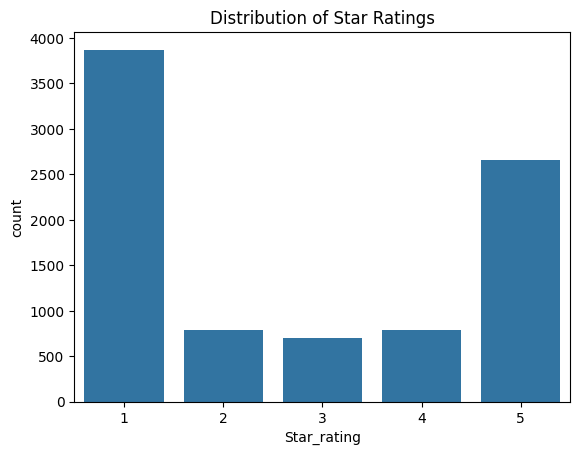

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Rating distribution
sns.countplot(data=df, x='Star_rating', order=sorted(df['Star_rating'].unique()))
plt.title("Distribution of Star Ratings")
plt.show()

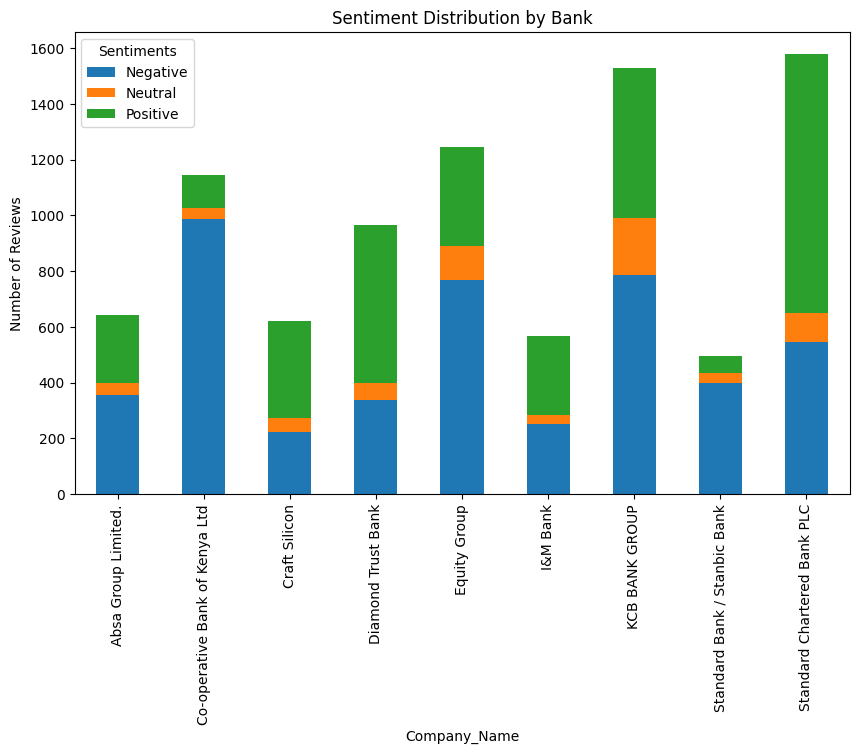

In [23]:
# Sentiment by company
sentiment_summary = df.groupby(['Company_Name', 'Sentiments']).size().unstack().fillna(0)
sentiment_summary.plot(kind='bar', stacked=True, figsize=(10,6), title='Sentiment Distribution by Bank')
plt.ylabel("Number of Reviews")
plt.show()

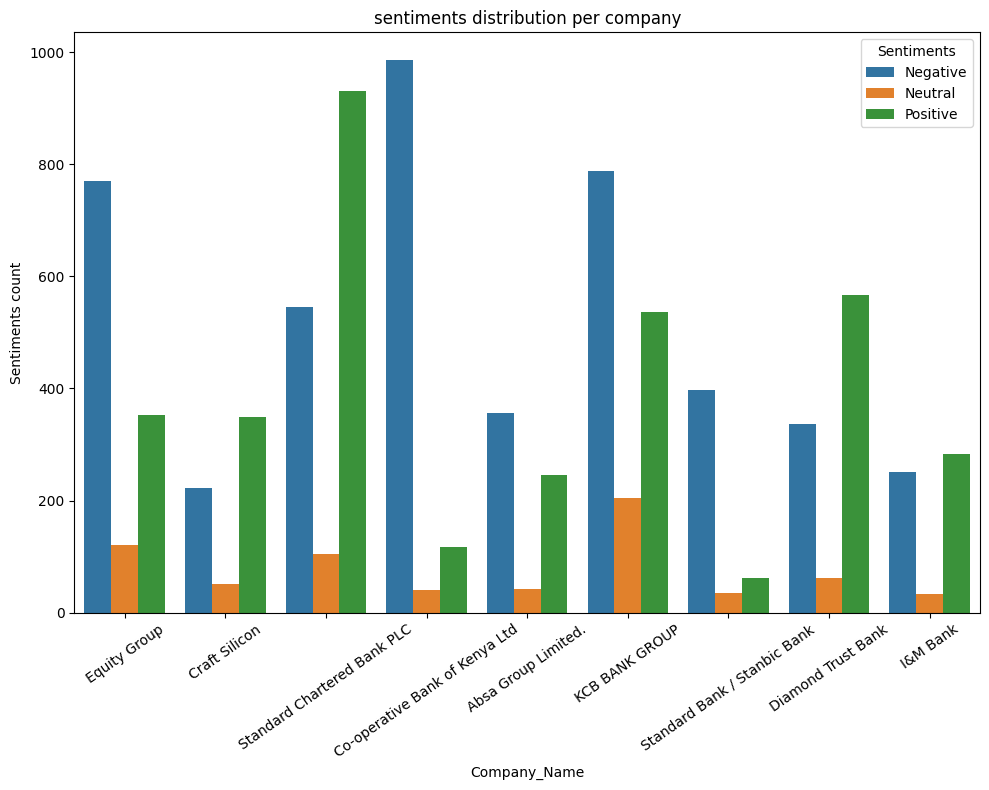

In [24]:
# 
plt.figure(figsize=(10,8))
sns.countplot(data=df, x='Company_Name', hue='Sentiments')
plt.ylabel('Sentiments count')
plt.xlabel('Company_Name')
plt.title('sentiments distribution per company')
plt.legend(title='Sentiments')
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()


<Axes: title={'center': 'Monthly Average Rating'}, xlabel='Month'>

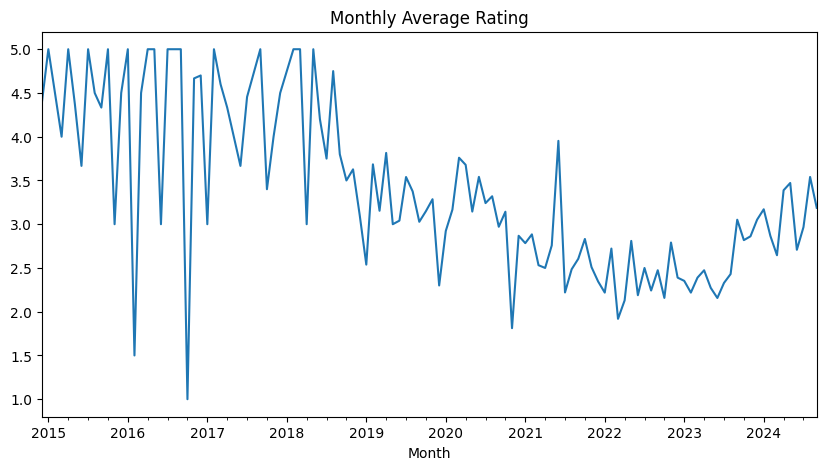

In [25]:
#Trends over time
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
df['Month'] = df['Time'].dt.to_period("M")

# Monthly average rating
monthly_rating = df.groupby('Month')['Star_rating'].mean()
monthly_rating.plot(title="Monthly Average Rating", figsize=(10,5))

Developer Reply Rate (%)
Company_Name
Absa Group Limited.               100.0
Co-operative Bank of Kenya Ltd    100.0
Craft Silicon                     100.0
Diamond Trust Bank                100.0
Equity Group                      100.0
I&M Bank                          100.0
KCB BANK GROUP                    100.0
Standard Bank / Stanbic Bank      100.0
Standard Chartered Bank PLC       100.0
Name: Has_Reply, dtype: float64


Text(0.5, 1.0, 'Ratings: Replied vs Not Replied')

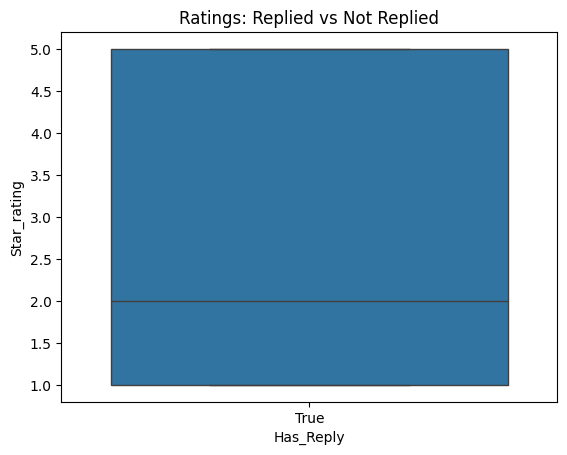

In [26]:
#Developer Engagement Analysis
# Calculate reply rate
df['Has_Reply'] = df['Developer_Reply'].apply(lambda x: x.strip().lower() != 'no reply')
reply_rate = df.groupby('Company_Name')['Has_Reply'].mean() * 100
print("Developer Reply Rate (%)")
print(reply_rate.sort_values(ascending=False))

# Does reply affect ratings?
sns.boxplot(data=df, x='Has_Reply', y='Star_rating')
plt.title("Ratings: Replied vs Not Replied")


In [27]:
# Most helpful reviews
most_helpful = df.sort_values(by='Helpful', ascending=False).head(10)
print(most_helpful[['Company_Name', 'Comments', 'Helpful']])

                        Company_Name  \
151                     Equity Group   
2277  Co-operative Bank of Kenya Ltd   
95                      Equity Group   
7721                  KCB BANK GROUP   
2130  Co-operative Bank of Kenya Ltd   
2194                  KCB BANK GROUP   
5878                  KCB BANK GROUP   
2268  Co-operative Bank of Kenya Ltd   
9                       Equity Group   
12                      Equity Group   

                                               Comments  Helpful  
151   disappointed app started great along way wasnt...    987.0  
2277  cant login using credentials app keeps taking ...    959.0  
95    ui amazing ux however needs lot improvement us...    867.0  
7721  ease accessing account fingerprints exceptiona...    852.0  
2130  app excellent frustrating user nothing works t...    817.0  
2194  encountered persistent issues app failing disp...    817.0  
5878  app play store beforenow back problems tried a...    808.0  
2268  personally love a

In [28]:
# Preview
df[['Star_rating', 'Sentiments']].head()

,Star_rating,Sentiments
0,1,Negative
1,1,Negative
2,2,Negative
3,3,Neutral
4,3,Neutral


In [29]:
# Count of sentiments
sentiment_counts = df['Sentiments'].value_counts().reindex(['Positive', 'Neutral', 'Negative'], fill_value=0)

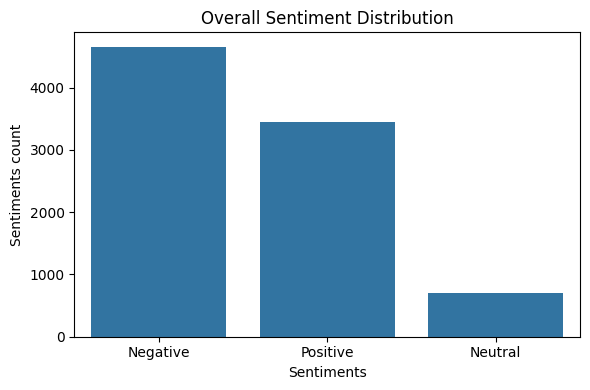

In [30]:
#Overall Sentiment Distribution

plt.figure(figsize=(6,4))
#sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
sns.countplot(data=df, x='Sentiments', order=df['Sentiments'].value_counts().index)
plt.title("Overall Sentiment Distribution")
#plt.ylabel("Number of Reviews")
plt.ylabel("Sentiments count")
plt.xlabel("Sentiments")
plt.tight_layout()
plt.show()

In [31]:
#Top Keywords by Sentiment
from collections import Counter

def get_top_words(df, sentiment_label, top_n=20):
    words = " ".join(df[df['Sentiments'] == sentiment_label]['Comments']).split()
    return Counter(words).most_common(top_n)

print("🔹 Top Positive Words:")
print(get_top_words(df, "Positive"))

print("\n🔹 Top Neutral Words:")
print(get_top_words(df, "Neutral"))

print("\n🔹 Top Negative Words:")
print(get_top_words(df, "Negative"))


🔹 Top Positive Words:
[('app', 1855), ('good', 579), ('easy', 459), ('best', 440), ('use', 439), ('bank', 406), ('great', 374), ('banking', 326), ('account', 262), ('one', 235), ('money', 221), ('like', 203), ('mobile', 192), ('love', 191), ('transactions', 179), ('excellent', 173), ('time', 172), ('convenient', 169), ('fast', 158), ('user', 155)]

🔹 Top Neutral Words:
[('app', 637), ('account', 140), ('good', 128), ('money', 118), ('update', 117), ('cant', 105), ('one', 91), ('time', 86), ('like', 80), ('use', 72), ('please', 72), ('even', 71), ('transaction', 71), ('bank', 69), ('mobile', 65), ('mpesa', 61), ('keeps', 59), ('balance', 58), ('transactions', 58), ('working', 58)]

🔹 Top Negative Words:
[('app', 4477), ('cant', 1241), ('account', 878), ('even', 810), ('bank', 763), ('time', 644), ('update', 628), ('keeps', 621), ('working', 583), ('one', 562), ('money', 506), ('use', 449), ('log', 434), ('customer', 431), ('work', 429), ('get', 409), ('doesnt', 404), ('banking', 400), (

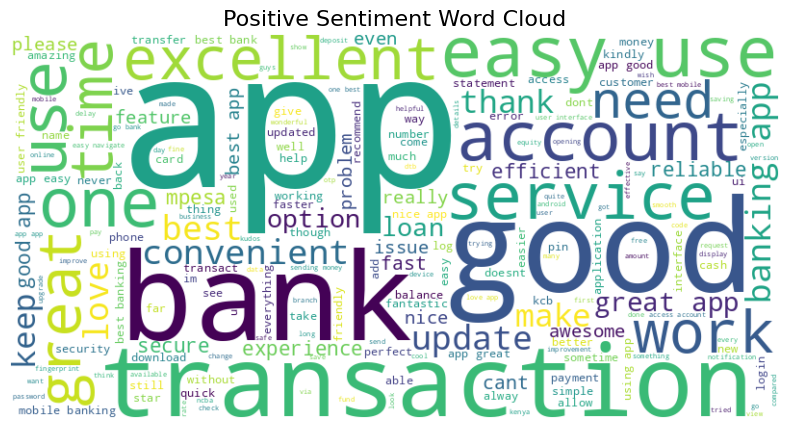

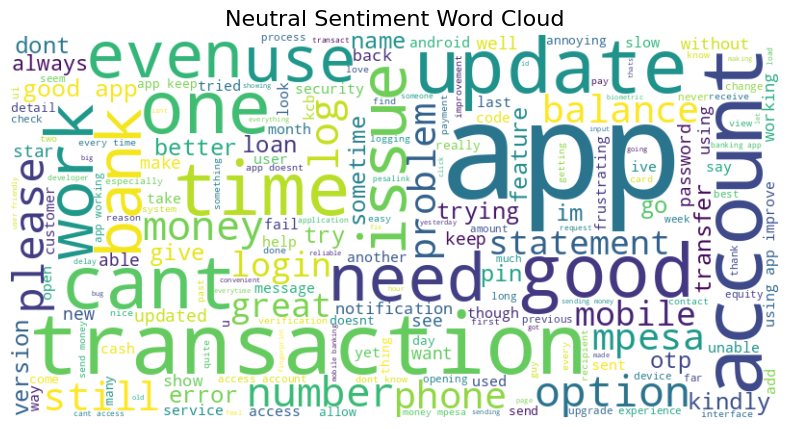

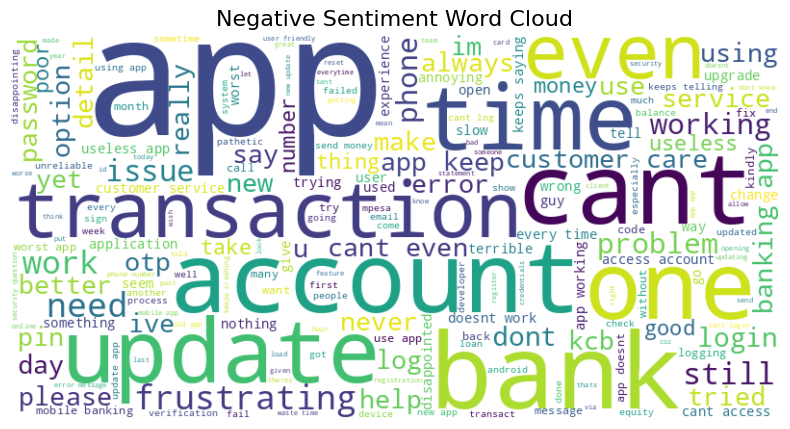

In [32]:
#WordCloud for Visual Comparison
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_wordcloud_by_sentiment(df, sentiment_label):
    text = " ".join(df[df['Sentiments'] == sentiment_label]['Comments'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"{sentiment_label} Sentiment Word Cloud", fontsize=16)
    plt.axis('off')
    plt.show()

plot_wordcloud_by_sentiment(df, "Positive")
plot_wordcloud_by_sentiment(df, "Neutral")
plot_wordcloud_by_sentiment(df, "Negative")


In [33]:
#Bigram Analysis
from sklearn.feature_extraction.text import CountVectorizer

def get_ngrams(df, sentiment_label, ngram_range=(2,2), top_n=15):
    comments = df[df['Sentiments'] == sentiment_label]['Comments']
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    X = vec.fit_transform(comments)
    sum_words = X.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_n]

print("🔹 Top Bigrams - Negative Sentiment:")
print(get_ngrams(df, "Negative", ngram_range=(2,2)))

print("🔹 Top Bigrams - Positive Sentiment:")
print(get_ngrams(df, "Positive", ngram_range=(2,2)))

🔹 Top Bigrams - Negative Sentiment:
[('customer care', 199), ('app keeps', 188), ('banking app', 170), ('app working', 134), ('useless app', 129), ('access account', 129), ('customer service', 127), ('doesnt work', 125), ('keeps saying', 109), ('mobile banking', 109), ('worst app', 106), ('app doesnt', 105), ('keeps telling', 99), ('using app', 95), ('use app', 89)]
🔹 Top Bigrams - Positive Sentiment:
[('easy use', 227), ('banking app', 129), ('great app', 127), ('good app', 110), ('mobile banking', 85), ('user friendly', 84), ('best app', 81), ('best banking', 69), ('app easy', 67), ('app good', 65), ('best bank', 55), ('app great', 47), ('nice app', 45), ('using app', 41), ('sending money', 35)]


In [34]:
# Extract Year and Month
df['Year'] = df['Time'].dt.year
df['Month'] = df['Time'].dt.month
df['YearMonth'] = df['Time'].dt.to_period('M')

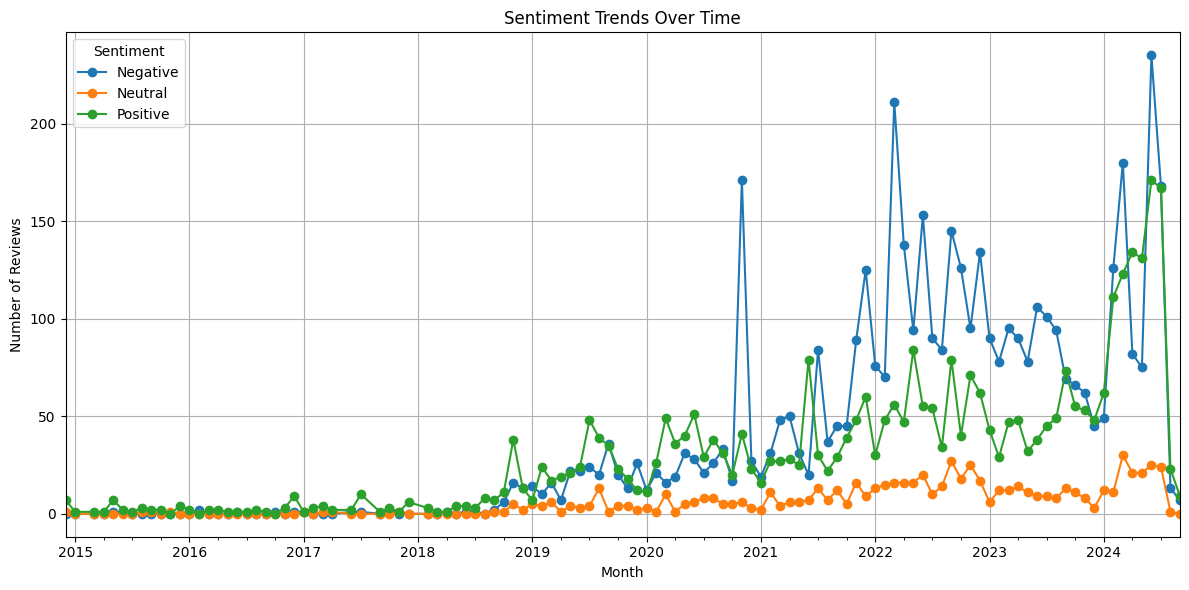

In [35]:
#Sentiment Trends Over Time
# Count sentiments per month
sentiment_trend = df.groupby(['YearMonth', 'Sentiments']).size().unstack().fillna(0)

# Plot
sentiment_trend.plot(kind='line', figsize=(12,6), marker='o')
plt.title('Sentiment Trends Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.legend(title='Sentiment')
plt.grid(True)
plt.tight_layout()
plt.show()

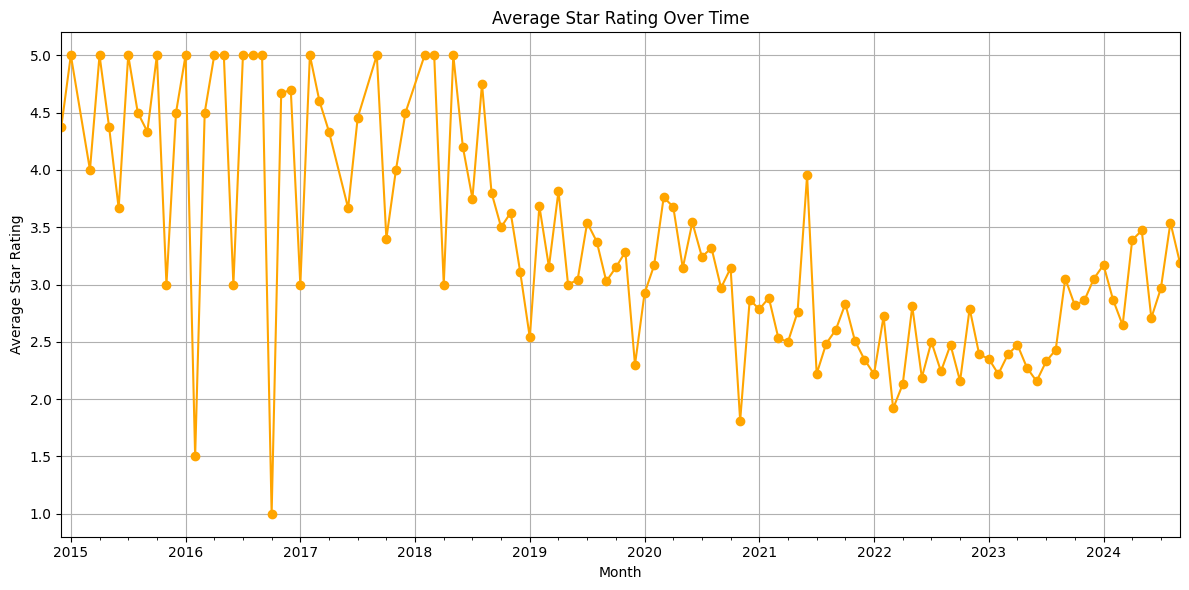

In [36]:
#Average Star Rating Over Time
# Calculate average star rating per month
rating_trend = df.groupby('YearMonth')['Star_rating'].mean()

# Plot
rating_trend.plot(kind='line', figsize=(12,6), color='orange', marker='o')
plt.title('Average Star Rating Over Time')
plt.xlabel('Month')
plt.ylabel('Average Star Rating')
plt.grid(True)
plt.tight_layout()
plt.show()



In [37]:
#Topic Modeling to Find Themes (LDA or NMF)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Vectorize comments
vectorizer = CountVectorizer(max_df=0.95, min_df=5, stop_words='english')
doc_term_matrix = vectorizer.fit_transform(df['Comments'])

# Apply LDA
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(doc_term_matrix)

# Display topics
words = vectorizer.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    print(f"Topic {idx+1}:")
    print([words[i] for i in topic.argsort()[-10:]])


Topic 1:
['services', 'love', 'great', 'mobile', 'easy', 'best', 'use', 'bank', 'banking', 'app']
Topic 2:
['works', 'service', 'interface', 'great', 'excellent', 'account', 'friendly', 'bank', 'app', 'user']
Topic 3:
['otp', 'use', 'transactions', 'awesome', 'work', 'application', 'reliable', 'security', 'app', 'good']
Topic 4:
['option', 'code', 'balance', 'transactions', 'send', 'transaction', 'mpesa', 'account', 'money', 'app']
Topic 5:
['login', 'work', 'try', 'log', 'account', 'time', 'working', 'keeps', 'update', 'app']


In [38]:
#olume of Reviews per Company
review_counts = df['Company_Name'].value_counts().reset_index()
review_counts.columns = ['Company_Name', 'Review_Count']

# Merge with sentiment info
sentiment_summary = df.groupby(['Company_Name', 'Sentiments']).size().unstack().fillna(0)
sentiment_summary = sentiment_summary.merge(review_counts, on='Company_Name')
sentiment_summary = sentiment_summary.sort_values('Review_Count', ascending=False)

sentiment_summary


,Company_Name,Negative,Neutral,Positive,Review_Count
8,Standard Chartered Bank PLC,545,104,930,1579
6,KCB BANK GROUP,788,204,536,1528
4,Equity Group,770,121,353,1244
1,Co-operative Bank of Kenya Ltd,986,41,118,1145
3,Diamond Trust Bank,337,62,567,966
0,Absa Group Limited.,356,42,245,643
2,Craft Silicon,222,51,349,622
5,I&M Bank,251,34,284,569
7,Standard Bank / Stanbic Bank,398,36,62,496


In [39]:
df.groupby('Sentiments')['Helpful'].mean()

Sentiments
Negative     8.586503
Neutral     13.640288
Positive     6.637340
Name: Helpful, dtype: float64

In [40]:
#Root Cause Analysis for Negative Sentiment
from sklearn.feature_extraction.text import CountVectorizer

# Filter for negative comments
neg_comments = df[df['Sentiments'] == 'Negative']['Comments']

# Extract keywords
vectorizer = CountVectorizer(stop_words='english', max_features=20)
X = vectorizer.fit_transform(neg_comments)
keywords = vectorizer.get_feature_names_out()
print(keywords)


['access' 'account' 'app' 'bank' 'banking' 'customer' 'doesnt' 'dont'
 'frustrating' 'keeps' 'log' 'login' 'money' 'new' 'time' 'try' 'update'
 'use' 'work' 'working']


In [42]:
#Tokenization Code Using Keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Convert to string just in case
texts = df['Comments'].astype(str).tolist()  

# Initialize the tokenizer
MAX_NUM_WORDS = 10000  
tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(texts)

# Pad sequences to ensure uniform input size
MAX_SEQUENCE_LENGTH = 100  
padded_sequences = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# Save word index for future use 
word_index = tokenizer.word_index
print(f"Found {len(word_index)} unique tokens.")

Found 9742 unique tokens.


In [43]:
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')  # download tokenizer data

# Tokenize text for Gensim
tokenized_texts = [word_tokenize(comment.lower()) for comment in texts]

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [45]:
#WORD2VEC EMBEDDING
# Train Word2Vec model
from gensim.models import Word2Vec
w2v_model = Word2Vec(sentences=tokenized_texts, 
                     vector_size=100,   # embedding size
                     window=5, 
                     min_count=1, 
                     workers=4, 
                     sg=1)  # sg=1 means skip-gram; use sg=0 for CBOW

# Save model if needed
w2v_model.save("word2vec.model")

In [46]:
#FASTTEXT EMBEDDING
from gensim.models import FastText

# Train FastText model
ft_model = FastText(sentences=tokenized_texts, 
                    vector_size=100, 
                    window=5, 
                    min_count=1, 
                    workers=4, 
                    sg=1)

# Save model if needed
ft_model.save("fasttext.model")

In [47]:
#Create Sentence Embeddings (for Classical ML)
def get_average_embedding(model, tokenized_texts, embedding_dim=100):
    embeddings = []
    for tokens in tokenized_texts:
        vectors = [model.wv[word] for word in tokens if word in model.wv]
        if vectors:
            avg_vec = np.mean(vectors, axis=0)
        else:
            avg_vec = np.zeros(embedding_dim)
        embeddings.append(avg_vec)
    return np.array(embeddings)

# Word2Vec sentence embeddings
X_w2v = get_average_embedding(w2v_model, tokenized_texts)

# FastText sentence embeddings
X_ft = get_average_embedding(ft_model, tokenized_texts)

# Sentiments(Target column)
y = df['Sentiments']  

In [48]:
#Classical ML Models
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X_w2v, y, test_size=0.2, random_state=42)

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
print("Logistic Regression:\n", classification_report(y_test, lr.predict(X_test)))

# Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
print("Naive Bayes:\n", classification_report(y_test, nb.predict(X_test)))

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
print("Random Forest:\n", classification_report(y_test, rf.predict(X_test)))


Logistic Regression:
               precision    recall  f1-score   support

    Negative       0.76      0.91      0.83       885
     Neutral       0.83      0.03      0.06       161
    Positive       0.82      0.78      0.80       713

    accuracy                           0.78      1759
   macro avg       0.80      0.58      0.56      1759
weighted avg       0.79      0.78      0.75      1759

Naive Bayes:
               precision    recall  f1-score   support

    Negative       0.84      0.75      0.79       885
     Neutral       0.19      0.50      0.28       161
    Positive       0.84      0.63      0.72       713

    accuracy                           0.68      1759
   macro avg       0.62      0.63      0.60      1759
weighted avg       0.78      0.68      0.72      1759

Random Forest:
               precision    recall  f1-score   support

    Negative       0.77      0.92      0.84       885
     Neutral       0.50      0.02      0.05       161
    Positive       0.82

In [49]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X_ft, y, test_size=0.2, random_state=42)

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
print("Logistic Regression:\n", classification_report(y_test, lr.predict(X_test)))

# Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
print("Naive Bayes:\n", classification_report(y_test, nb.predict(X_test)))

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
print("Random Forest:\n", classification_report(y_test, rf.predict(X_test)))

Logistic Regression:
               precision    recall  f1-score   support

    Negative       0.76      0.90      0.83       885
     Neutral       0.50      0.01      0.01       161
    Positive       0.80      0.79      0.80       713

    accuracy                           0.78      1759
   macro avg       0.69      0.57      0.54      1759
weighted avg       0.75      0.78      0.74      1759

Naive Bayes:
               precision    recall  f1-score   support

    Negative       0.84      0.76      0.80       885
     Neutral       0.20      0.50      0.28       161
    Positive       0.84      0.64      0.72       713

    accuracy                           0.69      1759
   macro avg       0.62      0.63      0.60      1759
weighted avg       0.78      0.69      0.72      1759

Random Forest:
               precision    recall  f1-score   support

    Negative       0.76      0.91      0.83       885
     Neutral       0.30      0.02      0.04       161
    Positive       0.81

In [50]:
#Embedding Matrix for DL Models
embedding_dim = 100
embedding_matrix_w2v = np.zeros((MAX_NUM_WORDS, embedding_dim))
for word, i in tokenizer.word_index.items():
    if i < MAX_NUM_WORDS and word in w2v_model.wv:
        embedding_matrix_w2v[i] = w2v_model.wv[word]

# Deep Learning with LSTM and CNN (using Word2Vec)

In [60]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_encoded = le.fit_transform(y)
# One-hot encode the integer labels
y_categorical = to_categorical(y_encoded)

In [55]:
print(y_encoded)

[0 0 0 ... 1 2 0]


In [61]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Conv1D, GlobalMaxPooling1D

# LSTM Model
model_lstm = Sequential([
    Embedding(input_dim=MAX_NUM_WORDS, 
              output_dim=embedding_dim, 
              input_length=MAX_SEQUENCE_LENGTH,
              weights=[embedding_matrix_w2v],
              trainable=False),
    LSTM(64),
    Dense(3, activation='softmax')  # change to softmax if multiclass
])

model_lstm.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_lstm.fit(padded_sequences,y_categorical, epochs=5, batch_size=32, validation_split=0.2)


C:\Users\HP\anaconda3\envs\tensorflow_new\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - accuracy: 0.5406 - loss: 0.9523 - val_accuracy: 0.4576 - val_loss: 0.9186
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.5424 - loss: 0.8994 - val_accuracy: 0.4576 - val_loss: 0.9197
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - accuracy: 0.5437 - loss: 0.9092 - val_accuracy: 0.4576 - val_loss: 0.9269
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 17s 77ms/step - accuracy: 0.5436 - loss: 0.9077 - val_accuracy: 0.4576 - val_loss: 0.9197
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 17s 75ms/step - accuracy: 0.5414 - loss: 0.8992 - val_accuracy: 0.4576 - val_loss: 0.9231


In [13]:
print(data)

      Company_Name             Time    Year  Star_rating  Helpful  \
0     Equity Group  August 10, 2022  2022.0          1.0    117.0   
1     Equity Group    July 18, 2024  2024.0          1.0      1.0   
2     Equity Group    June 24, 2024  2024.0          2.0     13.0   
3     Equity Group     May 17, 2024  2024.0          3.0     52.0   
4     Equity Group    July 10, 2024  2024.0          3.0      8.0   
...            ...              ...     ...          ...      ...   
8793      I&M Bank     June 6, 2022  2022.0          1.0      0.0   
8794      I&M Bank  August 10, 2023  2022.0          1.0      0.0   
8795      I&M Bank   April 26, 2024  2022.0          3.0      0.0   
8796      I&M Bank     July 4, 2024  2022.0          5.0      0.0   
8797      I&M Bank   August 3, 2023  2022.0          1.0      0.0   

                                               Comments  \
0     authentication process hell ive trying log rej...   
1     current update worst banking app ever one mome.

Text(0, 0.5, 'Count')

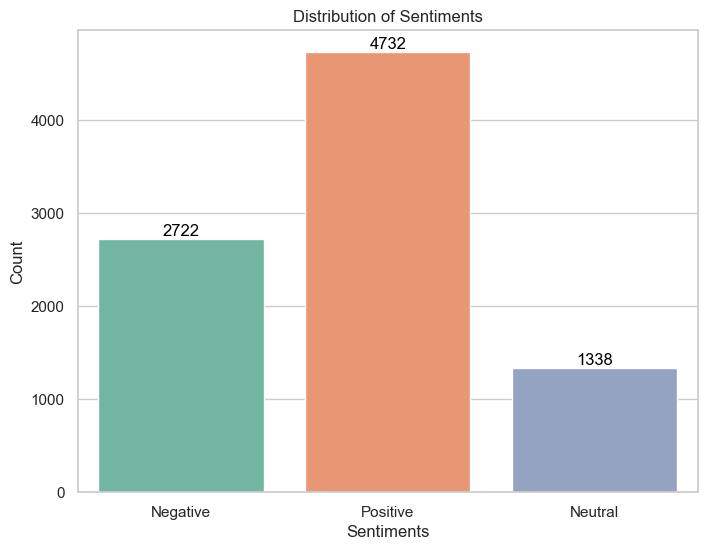

In [14]:
# Set the style for plots
sns.set(style="whitegrid")

#Distribution of Sentiment
# Create the plot
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Sentiments', data=data, hue='Sentiments', palette='Set2', legend=False)

# Add value labels to the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=12, color='black')

# Set titles and labels
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiments')
plt.ylabel('Count')

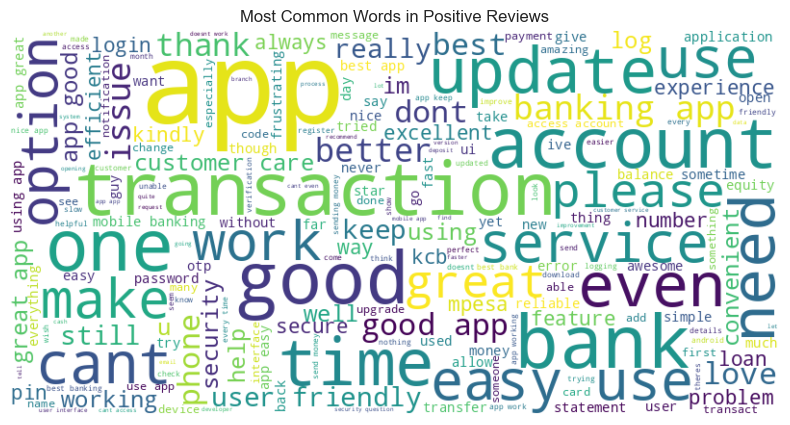

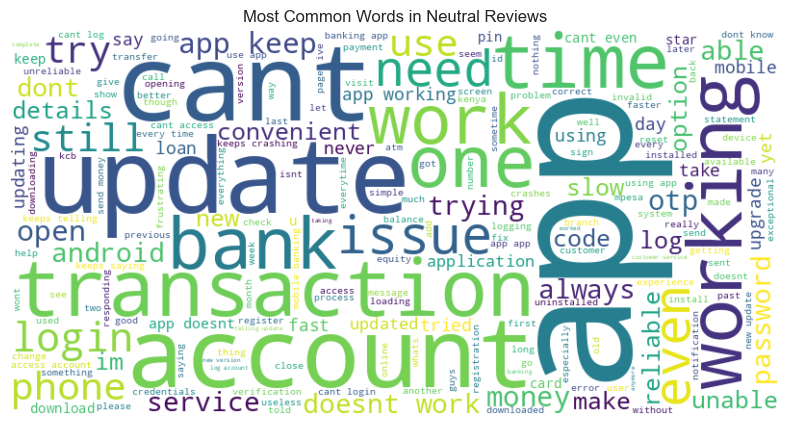

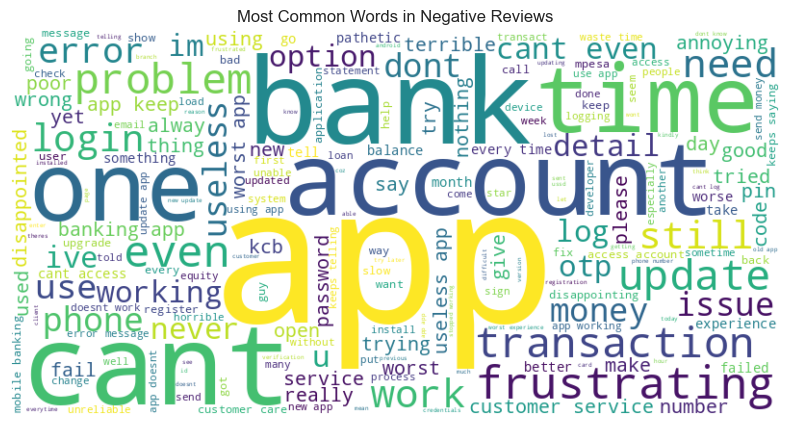

In [15]:
#Word Cloud for Each Sentiment
from wordcloud import WordCloud

for sentiment in ['Positive', 'Neutral', 'Negative']:
    text = " ".join(data[data['Sentiments'] == sentiment]['Comments'].dropna())
    
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Most Common Words in {sentiment.capitalize()} Reviews')
    plt.axis("off")
    plt.show()

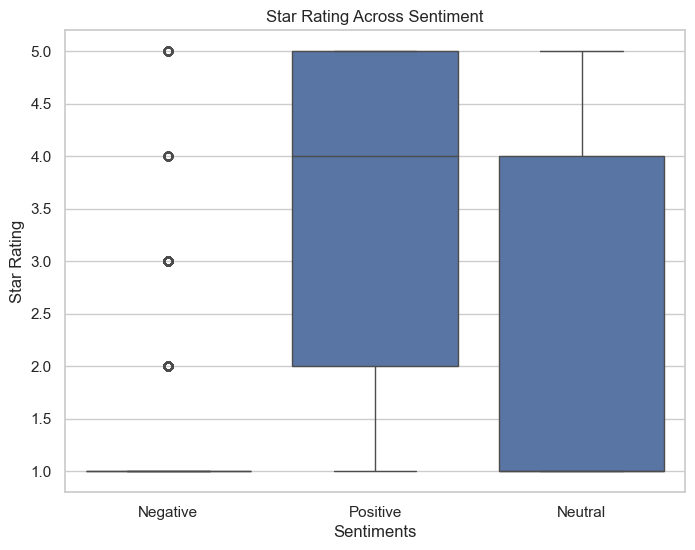

In [16]:
#Relationship Between Sentiment and Star Ratings: Are setiments and star ratings 
plt.figure(figsize=(8,6))
sns.boxplot(x='Sentiments', y='Star_rating', data=data)
plt.title('Star Rating Across Sentiment')
plt.xlabel('Sentiments')
plt.ylabel('Star Rating')
plt.show()

In [17]:
#Chi-Square Test: Categorical Factors
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(data['Sentiments'], data['Developer_Reply'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Test: Developer Replies vs Sentiment\nChi2: {chi2}, p-value: {p}")

Chi-Square Test: Developer Replies vs Sentiment
Chi2: 9968.605553611582, p-value: 0.2190777609858934


# Feature Extractions using Word2vec and Glove

In [18]:
import gensim
from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential

In [21]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [19]:
# Tokenize sentences
tokenized_comments = data['Comments'].apply(word_tokenize)

In [20]:
# Train Word2Vec model
word2vec_model = Word2Vec(sentences=tokenized_comments, vector_size=100, window=5, min_count=1, workers=4)
word2vec_model.save("word2vec.model")

In [21]:
print(word2vec_model)

Word2Vec<vocab=9742, vector_size=100, alpha=0.025>


In [22]:
# Load pre-trained GloVe embeddings
glove_path = "glove.6B.100d.txt"  # Download from Stanford NLP if not available
embeddings_index = {}
with open(glove_path, encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

In [23]:
# Tokenization and padding for deep learning
tokenizer = Tokenizer()
tokenizer.fit_on_texts(data['Comments'])
sequences = tokenizer.texts_to_sequences(data['Comments'])
word_index = tokenizer.word_index
p_sequences = pad_sequences(sequences, maxlen=100)

In [24]:
# Prepare embedding matrix
def get_embedding_matrix(embedding_type):
    embedding_dim = 100
    num_words = len(word_index) + 1
    embedding_matrix = np.zeros((num_words, embedding_dim))
    
    for word, i in word_index.items():
        if embedding_type == 'word2vec' and word in word2vec_model.wv:
            embedding_matrix[i] = word2vec_model.wv[word]
        elif embedding_type == 'glove' and word in embeddings_index:
            embedding_matrix[i] = embeddings_index[word]
    
    return embedding_matrix

In [25]:
# Create embedding matrix for both methods
word2vec_embedding_matrix = get_embedding_matrix('word2vec')
glove_embedding_matrix = get_embedding_matrix('glove')


# Feature Extractions using FastText

In [27]:
# Tokenize comments
tokenized_comments = [comment.split() for comment in data['Comments']]

# Train FastText model
fasttext_model = FastText(sentences=tokenized_comments, vector_size=100, window=5, min_count=1, sg=1, epochs=10)

# Function to compute FastText embeddings
def fasttext_embedding(tokens):
    return np.mean([fasttext_model.wv[word] for word in tokens if word in fasttext_model.wv], axis=0)

# Compute embeddings for all comments using list comprehension
data['Embeddings'] = [fasttext_embedding(tokens) for tokens in tokenized_comments]

C:\Users\HP\anaconda3\envs\tensorflow_new\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\HP\anaconda3\envs\tensorflow_new\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [30]:
# Drop rows where there is null values
data = data.dropna(subset=["Embeddings"])

In [31]:
print(data)

      Company_Name               Time    Year  Star_rating  Helpful  \
0     Equity Group    August 10, 2022  2022.0          1.0    117.0   
1     Equity Group      July 18, 2024  2024.0          1.0      1.0   
2     Equity Group      June 24, 2024  2024.0          2.0     13.0   
3     Equity Group       May 17, 2024  2024.0          3.0     52.0   
4     Equity Group      July 10, 2024  2024.0          3.0      8.0   
...            ...                ...     ...          ...      ...   
8792      I&M Bank  December 23, 2022  2022.0          5.0      0.0   
8793      I&M Bank       June 6, 2022  2022.0          1.0      0.0   
8794      I&M Bank    August 10, 2023  2022.0          1.0      0.0   
8795      I&M Bank     April 26, 2024  2022.0          3.0      0.0   
8796      I&M Bank       July 4, 2024  2022.0          5.0      0.0   

                                               Comments  \
0     authentication process hell ive trying log rej...   
1     current update worst ba

In [26]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
encoder_1 = LabelEncoder()
encoder_1.fit(data["Sentiments"])
data_encoded = encoder_1.transform(data["Sentiments"])
data["Sentiments"] = data_encoded


In [27]:
print(len(p_sequences))  # Should be 8792
print(len(data['Sentiments']))  # Should be 8792

8792
8792


In [28]:
data = data.dropna(subset=['Sentiments'])

In [29]:
print(len(p_sequences), len(data['Sentiments']))

8792 8792


In [30]:
p_sequences = p_sequences[:len(data)]

In [34]:
# Convert labels to categorical
#num_classes = len(data['Sentiments'].unique())
from tensorflow.keras.utils import to_categorical
y = to_categorical(data['Sentiments'])

In [35]:
# Split dataset before SMOTE
X_train, X_test, y_train, y_test = train_test_split(p_sequences, y, test_size=0.2, random_state=42, stratify=y)

In [36]:
# Apply SMOTE only on training data
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, np.argmax(y_train, axis=1))
y_train_resampled = to_categorical(y_train_resampled)

In [38]:
# Define models
def build_rnn_model(embedding_matrix):
    model = Sequential([
        Embedding(input_dim=embedding_matrix.shape[0], output_dim=100, weights=[embedding_matrix], input_length=100, trainable=True),
        SimpleRNN(128),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [39]:
def build_bilstm_model(embedding_matrix):
    model = Sequential([
        Embedding(input_dim=embedding_matrix.shape[0], output_dim=100, weights=[embedding_matrix], input_length=100, trainable=True),
        Bidirectional(LSTM(128)),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [40]:
def build_distilbert_model():
    tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
    bert_model = TFDistilBertModel.from_pretrained('distilbert-base-uncased')
    
    input_ids = tf.keras.layers.Input(shape=(100,), dtype=tf.int32, name='input_ids')
    attention_mask = tf.keras.layers.Input(shape=(100,), dtype=tf.int32, name='attention_mask')
    
    embeddings = bert_model(input_ids, attention_mask=attention_mask)[0][:, 0, :]
    output = Dense(y.shape[1], activation='softmax')(embeddings)
    
    model = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=output)
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [43]:
# Train and evaluate models
def train_and_evaluate_model(model_builder, embedding_matrix, model_name, embedding_name):
    print(f"Training {model_name} with {embedding_name} embeddings...")
    model = model_builder(embedding_matrix)
    
    early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    
    model.fit(X_train_resampled, y_train_resampled, epochs=5, batch_size=64, validation_data=(X_test, y_test))
    
    y_pred = np.argmax(model.predict(X_test), axis=1)
    y_test_labels = np.argmax(y_test, axis=1)
    
    accuracy = accuracy_score(y_test_labels, y_pred)
    print(f"{model_name} Model - Accuracy: {accuracy:.4f}")
    print(f"{model_name} Model Classification Report:\n{classification_report(y_test_labels, y_pred)}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test_labels, y_pred)}")

In [44]:
# Train RNN and BiLSTM
from tensorflow.keras.layers import Embedding, LSTM, Dense, SimpleRNN, Bidirectional, Dropout
from sklearn.metrics import accuracy_score
#from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
for embedding_name, embedding_matrix in zip(["Word2Vec", "GloVe"], [get_embedding_matrix('word2vec'), get_embedding_matrix('glove')]):
    train_and_evaluate_model(build_rnn_model, embedding_matrix, "RNN", embedding_name)
    train_and_evaluate_model(build_bilstm_model, embedding_matrix, "BiLSTM", embedding_name)

Training RNN with Word2Vec embeddings...
Epoch 1/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 15s 66ms/step - accuracy: 0.4750 - loss: 1.0830 - val_accuracy: 0.5674 - val_loss: 0.9340
Epoch 2/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.5277 - loss: 0.9763 - val_accuracy: 0.6492 - val_loss: 0.7712
Epoch 3/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.6850 - loss: 0.7311 - val_accuracy: 0.6475 - val_loss: 0.8078
Epoch 4/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.8226 - loss: 0.4856 - val_accuracy: 0.5912 - val_loss: 1.0349
Epoch 5/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.8957 - loss: 0.3142 - val_accuracy: 0.5156 - val_loss: 1.5248
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step  
RNN Model - Accuracy: 0.5156
RNN Model Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.40      0.47       544
           1       0.25      0.77      0.38       268
           2       0.91      0.51      0.65     

C:\Users\HP\anaconda3\envs\tensorflow_new\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


178/178 ━━━━━━━━━━━━━━━━━━━━ 50s 247ms/step - accuracy: 0.5112 - loss: 0.9897 - val_accuracy: 0.6100 - val_loss: 0.8077
Epoch 2/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 42s 235ms/step - accuracy: 0.6360 - loss: 0.8143 - val_accuracy: 0.6049 - val_loss: 0.8763
Epoch 3/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 43s 241ms/step - accuracy: 0.7052 - loss: 0.6923 - val_accuracy: 0.7328 - val_loss: 0.6225
Epoch 4/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 41s 230ms/step - accuracy: 0.7997 - loss: 0.5127 - val_accuracy: 0.6936 - val_loss: 0.7530
Epoch 5/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 41s 231ms/step - accuracy: 0.8634 - loss: 0.3664 - val_accuracy: 0.7277 - val_loss: 0.7981
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step
BiLSTM Model - Accuracy: 0.7277
BiLSTM Model Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.81      0.70       544
           1       0.51      0.58      0.55       268
           2       0.91      0.72      0.81       947

    accuracy                      

C:\Users\HP\anaconda3\envs\tensorflow_new\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


178/178 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 0.4562 - loss: 1.1374 - val_accuracy: 0.6038 - val_loss: 0.8668
Epoch 2/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.5862 - loss: 0.9066 - val_accuracy: 0.6549 - val_loss: 0.7928
Epoch 3/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.6212 - loss: 0.8505 - val_accuracy: 0.6669 - val_loss: 0.7857
Epoch 4/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.6913 - loss: 0.7348 - val_accuracy: 0.6839 - val_loss: 0.7573
Epoch 5/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.7415 - loss: 0.6460 - val_accuracy: 0.6850 - val_loss: 0.7596
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step  
RNN Model - Accuracy: 0.6850
RNN Model Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.63      0.62       544
           1       0.45      0.71      0.55       268
           2       0.86      0.71      0.78       947

    accuracy                           0.69   

C:\Users\HP\anaconda3\envs\tensorflow_new\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


178/178 ━━━━━━━━━━━━━━━━━━━━ 50s 247ms/step - accuracy: 0.5328 - loss: 0.9662 - val_accuracy: 0.6794 - val_loss: 0.7466
Epoch 2/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 81s 241ms/step - accuracy: 0.6904 - loss: 0.7287 - val_accuracy: 0.7288 - val_loss: 0.6285
Epoch 3/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 45s 255ms/step - accuracy: 0.7388 - loss: 0.6184 - val_accuracy: 0.7538 - val_loss: 0.6128
Epoch 4/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 48s 267ms/step - accuracy: 0.7844 - loss: 0.5291 - val_accuracy: 0.8033 - val_loss: 0.5249
Epoch 5/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 77s 240ms/step - accuracy: 0.8307 - loss: 0.4366 - val_accuracy: 0.7817 - val_loss: 0.5710
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step
BiLSTM Model - Accuracy: 0.7817
BiLSTM Model Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.78      0.75       544
           1       0.57      0.74      0.65       268
           2       0.91      0.80      0.85       947

    accuracy                      

In [88]:
# Clear memory before starting
import gc
gc.collect()
tf.keras.backend.clear_session()

In [89]:
# Load dataset
data['tokenized_comments'] = data['Comments'].apply(word_tokenize)

# Load Word2Vec
word2vec_model = Word2Vec(sentences=data['tokenized_comments'], vector_size=100, window=5, min_count=1, workers=4)

def get_sentence_embedding(sentence, embedding_type='word2vec'):
    tokens = word_tokenize(sentence)
    embeddings = []
    
    for word in tokens:
        if embedding_type == 'word2vec' and word in word2vec_model.wv:
            embeddings.append(word2vec_model.wv[word])
        elif embedding_type == 'glove' and word in embeddings_index:
            embeddings.append(embeddings_index[word])
            return np.mean(embeddings, axis=0) if embeddings else np.zeros(100)

In [90]:
# Convert sentences to embeddings
data['w2v_embeddings'] = data['Comments'].apply(lambda x: get_sentence_embedding(x, 'word2vec'))
data['glove_embeddings'] = data['Comments'].apply(lambda x: get_sentence_embedding(x, 'glove'))

In [91]:
# Tokenize for DistilBERT
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
tokens = tokenizer(data['Comments'].tolist(), padding=True, truncation=True, max_length=64, return_tensors='tf')

In [82]:
# Check if GPU is available
def get_device():
    if tf.config.list_physical_devices('GPU'):
        print("Using GPU")
        return tf.device('/GPU:0')
    else:
        print("Using CPU")
        return tf.device('/CPU:0')

device = get_device()

Using CPU


In [92]:
# Load DistilBERT
bert_model = TFDistilBertModel.from_pretrained("distilbert-base-uncased")
bert_output = bert_model(tokens['input_ids'], attention_mask=tokens['attention_mask'])

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.weight', 'vocab_transform.weight', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


ResourceExhaustedError: Exception encountered when calling layer 'out_lin' (type Dense).

{{function_node __wrapped__BiasAdd_device_/job:localhost/replica:0/task:0/device:CPU:0}} OOM when allocating tensor with shape[8792,64,768] and type float on /job:localhost/replica:0/task:0/device:CPU:0 by allocator mklcpu [Op:BiasAdd] name: 

Call arguments received by layer 'out_lin' (type Dense):
  • inputs=tf.Tensor(shape=(8792, 64, 768), dtype=float32)

In [93]:
# Extract sentence embeddings from DistilBERT
bert_embeddings = tf.reduce_mean(bert_output.last_hidden_state, axis=1).numpy()

# Concatenate features
X_glove = np.hstack((bert_embeddings, np.vstack(data['glove_embeddings'].values)))
X_w2v = np.hstack((bert_embeddings, np.vstack(data['w2v_embeddings'].values)))
y = data['Sentiments'].values

NameError: name 'bert_output' is not defined

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_glove, y, test_size=0.2, random_state=42)

# Build Classifier
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
# Train Model
history = model.fit(X_train, y_train, validation_split=0.2, epochs=5, batch_size=8)

# Evaluate Model
y_pred = np.argmax(model.predict(X_test), axis=1)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

In [72]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout

def build_lstm_model(embedding_matrix, vocab_size, embedding_dim):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix], input_length=100, trainable=False),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(32)),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')  # Assuming binary sentiment classification
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

vocab_size = len(word_index) + 1
embedding_dim = 100

# Train with Word2Vec
word2vec_model = build_lstm_model(word2vec_embedding_matrix, vocab_size, embedding_dim)
word2vec_model.fit(p_sequences, data['Sentiments'], epochs=5, batch_size=32, validation_split=0.2)

# Train with GloVe
glove_model = build_lstm_model(glove_embedding_matrix, vocab_size, embedding_dim)
glove_model.fit(p_sequences, data['Sentiments'], epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 41s 134ms/step - accuracy: 0.1521 - loss: -3.1946 - val_accuracy: 0.1666 - val_loss: -21.0186
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 27s 122ms/step - accuracy: 0.1537 - loss: -24.0645 - val_accuracy: 0.1666 - val_loss: -59.2945
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 29s 130ms/step - accuracy: 0.1509 - loss: -55.2815 - val_accuracy: 0.1666 - val_loss: -118.5417
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 44s 142ms/step - accuracy: 0.1485 - loss: -115.1276 - val_accuracy: 0.1666 - val_loss: -196.2033
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 28s 127ms/step - accuracy: 0.1478 - loss: -168.5070 - val_accuracy: 0.1666 - val_loss: -289.3108
Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 41s 145ms/step - accuracy: 0.1541 - loss: -3.1514 - val_accuracy: 0.1666 - val_loss: -18.7587
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 30s 138ms/step - accuracy: 0.1444 - loss: -22.9511 - val_accuracy: 0.1666 - val_loss: -57.5396
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 29s 129ms/step - acc

In [74]:
# Evaluate LSTM (GloVe)
glove_acc = glove_model.evaluate(p_sequences, data['Sentiments'])[1]

# Evaluate LSTM (Word2Vec)
word2vec_acc = word2vec_model.evaluate(p_sequences, data['Sentiments'])[1]

275/275 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - accuracy: 0.1272 - loss: -497.8759
275/275 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.1272 - loss: -203.4790


In [76]:
from transformers import DistilBertTokenizer

# Load DistilBERT tokenizer
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

# Tokenize comments
encoded_inputs = tokenizer(list(data['Comments']), padding=True, truncation=True, max_length=100, return_tensors="tf")

X_train = encoded_inputs['input_ids']
X_train_mask = encoded_inputs['attention_mask']
y_train = data['Sentiments'].values

In [ ]:
from transformers import TFDistilBertModel
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling1D
from tensorflow.keras.models import Model

def build_distilbert_model():
    distilbert_model = TFDistilBertModel.from_pretrained("distilbert-base-uncased")
    
    input_ids = Input(shape=(100,), dtype=tf.int32, name="input_ids")
    attention_mask = Input(shape=(100,), dtype=tf.int32, name="attention_mask")
    
    bert_output = distilbert_model(input_ids, attention_mask=attention_mask)[0]  # Last hidden state
    pooled_output = GlobalAveragePooling1D()(bert_output)  # Reduce dimensionality
    dense = Dense(64, activation="relu")(pooled_output)
    dropout = Dropout(0.3)(dense)
    output = Dense(1, activation="sigmoid")(dropout)  # Binary classification

    model = Model(inputs=[input_ids, attention_mask], outputs=output)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    
    return model

distilbert_model = build_distilbert_model()

In [24]:
X = np.array(data['Embeddings'].tolist())  # FastText embeddings as input features
y = np.array(data['Sentiments'])  # Sentiment labels

In [25]:
#pip install imblearn

In [26]:
from sklearn.model_selection import train_test_split

# Split data: 80% training, 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}")

Training set: (7027, 100), Validation set: (1757, 100)


In [27]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Balanced Training set: {X_train_bal.shape}, {y_train_bal.shape}")

Balanced Training set: (11355, 100), (11355,)


In [28]:
print("Counts of label '0' - Before Oversampling:{}, After OverSampling: {}".format(sum(y_train == 0),sum(y_train_bal == 0)))
print("Counts of label '1' - Before Oversampling:{}, After OverSampling: {}".format(sum(y_train == 1),sum(y_train_bal == 1)))
print("Counts of label '2' - Before Oversampling:{}, After OverSampling: {}".format(sum(y_train == 2),sum(y_train_bal == 2)))

Counts of label '0' - Before Oversampling:2178, After OverSampling: 3785
Counts of label '1' - Before Oversampling:1064, After OverSampling: 3785
Counts of label '2' - Before Oversampling:3785, After OverSampling: 3785


In [29]:
# Reshape function
def reshape_for_rnn(X):
    return X.reshape((X.shape[0], 1, X.shape[1]))  # (samples, 1 timestep, features)

# Reshape training and validation sets
X_train_rnn = reshape_for_rnn(X_train_bal)
X_val_rnn = reshape_for_rnn(X_val)

print(f"RNN-ready X_train shape: {X_train_rnn.shape}")
print(f"RNN-ready X_val shape: {X_val_rnn.shape}")

RNN-ready X_train shape: (11355, 1, 100)
RNN-ready X_val shape: (1757, 1, 100)


In [30]:
from keras.models import Sequential
from tensorflow.keras.optimizers import Adam
# Build the RNN model
model_rnn = Sequential([
    SimpleRNN(128, input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2]), dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')  # Assuming 3 classes: negative, neutral, positive
])

# Compile the model
model_rnn.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])

# Train the RNN model
model_rnn.fit(X_train_rnn, y_train_bal, epochs=20, batch_size=64, validation_data=(X_val_rnn, y_val))

C:\Users\HP\anaconda3\envs\tensorflow_new\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5056 - loss: 0.9699 - val_accuracy: 0.6659 - val_loss: 0.7801
Epoch 2/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5942 - loss: 0.8621 - val_accuracy: 0.6944 - val_loss: 0.7165
Epoch 3/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6097 - loss: 0.8398 - val_accuracy: 0.6511 - val_loss: 0.7988
Epoch 4/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6184 - loss: 0.8191 - val_accuracy: 0.6722 - val_loss: 0.7639
Epoch 5/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6114 - loss: 0.8178 - val_accuracy: 0.6659 - val_loss: 0.7790
Epoch 6/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6224 - loss: 0.8142 - val_accuracy: 0.6602 - val_loss: 0.7803
Epoch 7/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6174 - loss: 0.8112 - val_accuracy: 0.6443 - val_loss: 0.7992
Epoch 8/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6306 - loss: 0.7984 - val_accuracy: 0

In [31]:
from tensorflow.keras.layers import Dropout
# Build BiLSTM model
bilstm_model = Sequential()
bilstm_model.add(Bidirectional(LSTM(128, input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2]))))
bilstm_model.add(Dropout(0.5))
bilstm_model.add(Dense(64, activation='relu'))
bilstm_model.add(Dropout(0.5))
bilstm_model.add(Dense(len(np.unique(y_train_bal)), activation='softmax'))

# Compile the model
bilstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
bilstm_history = bilstm_model.fit(
    X_train_rnn, y_train_bal,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_rnn, y_val),
    verbose=1
)

Epoch 1/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.4691 - loss: 1.0058 - val_accuracy: 0.6266 - val_loss: 0.8029
Epoch 2/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5747 - loss: 0.8886 - val_accuracy: 0.6244 - val_loss: 0.8365
Epoch 3/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6128 - loss: 0.8431 - val_accuracy: 0.6682 - val_loss: 0.7394
Epoch 4/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6201 - loss: 0.8200 - val_accuracy: 0.6448 - val_loss: 0.8026
Epoch 5/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6274 - loss: 0.8185 - val_accuracy: 0.6625 - val_loss: 0.7865
Epoch 6/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6348 - loss: 0.8063 - val_accuracy: 0.6767 - val_loss: 0.7475
Epoch 7/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6493 - loss: 0.7768 - val_accuracy: 0.6853 - val_loss: 0.7251
Epoch 8/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6493 - loss: 0.7774 - val_acc

In [32]:
from transformers import DistilBertTokenizer
# Split the data into training and validation sets
train_df, test_df = train_test_split(data, test_size=0.2, random_state=42)

# Load DistilBERT tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
#bert_model = TFDistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=len(np.unique(train_df)))
# Tokenize the text data after splitting
train_encodings = tokenizer(train_df['Comments'].tolist(), truncation=True, padding=True, max_length=128, return_tensors='tf')
val_encodings = tokenizer(test_df['Comments'].tolist(), truncation=True, padding=True, max_length=128, return_tensors='tf')

# Prepare TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    train_df['Sentiments'].values
)).shuffle(500).batch(8)

val_dataset = tf.data.Dataset.from_tensor_slices((
    dict(val_encodings),
    test_df['Sentiments'].values
)).batch(8)

from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification
# Define the DistilBERT model
bert_model = TFDistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=3)
#Train the DistilBERT Model
# Compile the model
bert_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
bert_history = bert_model.fit(
    train_dataset,
    epochs=3,  # DistilBERT requires fewer epochs
    validation_data=val_dataset,
    verbose=1
)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_layer_norm.bias', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 


Epoch 1/3


879/879 [==============================] - 5105s 6s/step - loss: 1.1249 - accuracy: 0.5023 - val_loss: 1.0986 - val_accuracy: 0.4667
Epoch 2/3
879/879 [==============================] - 3647s 4s/step - loss: 1.0986 - accuracy: 0.5031 - val_loss: 1.0986 - val_accuracy: 0.4667
Epoch 3/3
879/879 [==============================] - 4128s 5s/step - loss: 1.0986 - accuracy: 0.5028 - val_loss: 1.0986 - val_accuracy: 0.4667


In [35]:
# Evaluate RNN Model on Test Data
rnn_loss, rnn_accuracy = model_rnn.evaluate(X_val_rnn, y_val, verbose=1)
print(f"RNN Model - Loss: {rnn_loss}, Accuracy: {rnn_accuracy}")

# Get Predictions
y_pred_rnn = model_rnn.predict(X_val_rnn)
y_pred_rnn_labels = y_pred_rnn.argmax(axis=1)  # Convert probabilities to class labels

# Classification Report
print("RNN Model Classification Report:")
print(classification_report(y_val, y_pred_rnn_labels))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_labels))


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6929 - loss: 0.7059 
RNN Model - Loss: 0.708986222743988, Accuracy: 0.6835514903068542
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
RNN Model Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.75      0.65       544
           1       0.48      0.53      0.51       266
           2       0.86      0.69      0.76       947

    accuracy                           0.68      1757
   macro avg       0.64      0.66      0.64      1757
weighted avg       0.71      0.68      0.69      1757

Confusion Matrix:
[[410  72  62]
 [ 74 138  54]
 [195  61 691]]


In [34]:
# Predict probabilities on test set
y_pred_bilstm = bilstm_model.predict(X_val_rnn)
# Convert predicted probabilities to class labels
y_pred_labels = np.argmax(y_pred_bilstm, axis=1)
from sklearn.metrics import classification_report, confusion_matrix

# Print classification report
print("BiLSTM Classification Report:")
print(classification_report(y_val, y_pred_labels))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_labels))

55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
BiLSTM Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.75      0.67       544
           1       0.51      0.52      0.51       266
           2       0.86      0.73      0.79       947

    accuracy                           0.71      1757
   macro avg       0.66      0.67      0.66      1757
weighted avg       0.73      0.71      0.71      1757

Confusion Matrix:
[[410  72  62]
 [ 74 138  54]
 [195  61 691]]


In [41]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions (logits) on validation data
val_logits = bert_model.predict(val_dataset).logits

# Convert logits to predicted class labels
val_preds = np.argmax(val_logits, axis=1)

# True labels from validation set
true_labels = test_df['Sentiments'].values

# Classification report: precision, recall, F1-score
print("Classification Report:")
print(classification_report(true_labels, val_preds, digits=4))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(true_labels, val_preds))

220/220 [==============================] - 204s 928ms/step
Classification Report:
              precision    recall  f1-score   support

           0     0.0948    0.0412    0.0574       534
           1     0.0000    0.0000    0.0000       271
           2     0.5233    0.8382    0.6443       952

    accuracy                         0.4667      1757
   macro avg     0.2060    0.2931    0.2339      1757
weighted avg     0.3124    0.4667    0.3666      1757

Confusion Matrix:
[[ 22   0 512]
 [ 56   0 215]
 [154   0 798]]


C:\Users\HP\anaconda3\envs\tensorflow_new\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\envs\tensorflow_new\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\envs\tensorflow_new\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le